https://velog.io/@kungsboy/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D-02-02.%EB%A1%9C%EC%A7%80%EC%8A%A4%ED%8B%B1-%ED%9A%8C%EA%B7%80-Breast-Cancer

https://perconsi.tistory.com/83

In [9]:
import pandas as pd

# 데이터 불러오기
df=pd.read_csv('https://bit.ly/fish_csv_data')
df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [12]:
print(df.shape)
print(df.info())
print(df.describe())

(159, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    object 
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.6+ KB
None
            Weight      Length    Diagonal      Height       Width
count   159.000000  159.000000  159.000000  159.000000  159.000000
mean    398.326415   28.415723   31.227044    8.970994    4.417486
std     357.978317   10.716328   11.610246    4.286208    1.685804
min       0.000000    8.400000    8.800000    1.728400    1.047600
25%     120.000000   21.000000   23.150000    5.944800    3.385650
50%     273.000000   27.300000   29.400000    7.786000    4.248500
75%     650.000000   35.500000   39.650000   12.3

In [13]:
corr = df.corr(numeric_only=True)
print(corr)

            Weight    Length  Diagonal    Height     Width
Weight    1.000000  0.918618  0.923044  0.724345  0.886507
Length    0.918618  1.000000  0.994103  0.640441  0.873547
Diagonal  0.923044  0.994103  1.000000  0.703409  0.878520
Height    0.724345  0.640441  0.703409  1.000000  0.792881
Width     0.886507  0.873547  0.878520  0.792881  1.000000


✔ 직관적 해석
Weight ↑ → 큰 물고기
Length / Diagonal ↑ → 길쭉한 물고기
Height / Width ↑ → 두꺼운 물고기

In [14]:
corr['Weight'].sort_values(ascending=False)

,Weight
Weight,1.000000
Diagonal,0.923044
Length,0.918618
Width,0.886507
Height,0.724345


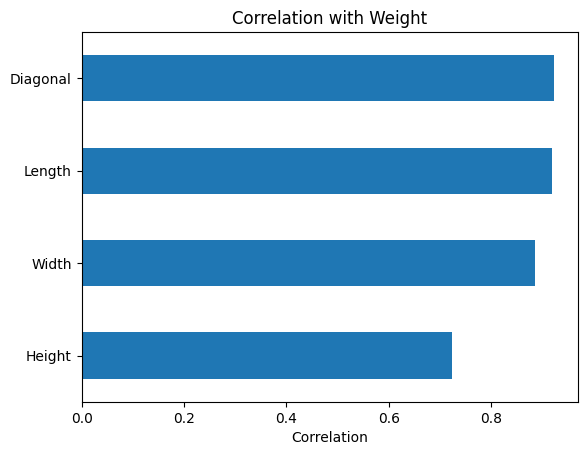

In [15]:
import matplotlib.pyplot as plt

corr['Weight'].drop('Weight').sort_values().plot(kind='barh')

plt.title("Correlation with Weight")
plt.xlabel("Correlation")

plt.show()

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

df

,Species,Weight,Length,Diagonal,Height,Width
0,0,242.0,25.4,30.0,11.5200,4.0200
1,0,290.0,26.3,31.2,12.4800,4.3056
2,0,340.0,26.5,31.1,12.3778,4.6961
3,0,363.0,29.0,33.5,12.7300,4.4555
4,0,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,5,12.2,12.2,13.4,2.0904,1.3936
155,5,13.4,12.4,13.5,2.4300,1.2690
156,5,12.2,13.0,13.8,2.2770,1.2558
157,5,19.7,14.3,15.2,2.8728,2.0672


In [20]:
X = df.drop('Species', axis=1)
y = df['Species']

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, average='macro'))
print("Recall:", recall_score(y_test, pred, average='macro'))
print("F1:", f1_score(y_test, pred, average='macro'))

# ✔ 해석
# Accuracy → 전체 정확도
# Precision / Recall → 클래스별 성능
# F1 → 균형
# 👉 물고기 분류는 비교적 잘 맞는 편

Accuracy: 0.875
Precision: 0.6703296703296704
Recall: 0.7142857142857143
F1: 0.6883116883116883


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
import pandas as pd

importance = pd.Series(model.coef_[0], index=X.columns)
importance = importance.sort_values(key=abs, ascending=False)

print(importance)

Height      2.866324
Diagonal    0.639772
Width      -0.293382
Weight     -0.178901
Length     -0.115180
dtype: float64


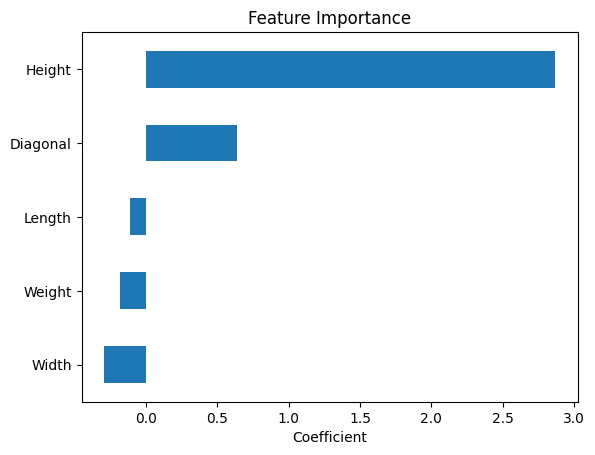

In [24]:
importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Coefficient")

plt.show()

https://perconsi.tistory.com/83